In [32]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from genieclust.cluster_validity import (
    calinski_harabasz_index,
    dunnowa_index,
    generalised_dunn_index,
    negated_ball_hall_index,
    negated_davies_bouldin_index,
    negated_wcss_index,
    silhouette_index,
    silhouette_w_index,
    wcnn_index,
)
from genieclust.compare_partitions import normalized_clustering_accuracy
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings("ignore", category=UserWarning)

sns.set_style("whitegrid")
sns.set_palette("Set2")

# Load data

In [2]:
labels_df = np.load("../outputs/all_experiments.pkl", allow_pickle=True)
labels_df = pd.DataFrame(labels_df).T.reset_index().rename(columns={"index": "dataset"})

labels_df = labels_df.assign(
    _algorithm_labels=labels_df["labels"].map(
        lambda x: list(x.items()) if isinstance(x, dict) else []
    )
).explode("_algorithm_labels", ignore_index=True)
labels_df[["algorithm", "labels"]] = pd.DataFrame(
    labels_df["_algorithm_labels"].tolist(), index=labels_df.index
)
labels_df = labels_df.drop(columns=["_algorithm_labels"])

dataset_rows = labels_df.drop_duplicates("dataset")[["dataset", "data"]].reset_index(drop=True)
datasets = dict(zip(dataset_rows["dataset"], dataset_rows["data"], strict=False))

In [3]:
labels_df.columns

Index(['dataset', 'k', 'labels', 'true_labels', 'data', 'algorithm'], dtype='str')

In [ ]:
if Path.exists(Path("../outputs/tables/metrics.json")):
    metrics_df = pd.read_json("../outputs/tables/metrics.json", orient="records", lines=True)
    print("Loaded metrics from file.")
else:
    metrics = []

    def safe_compute(metric_fn, *args):
        try:
            return metric_fn(*args)
        except Exception:
            return np.nan

    for row in labels_df.itertuples():
        dataset_name = row.dataset
        algorithm = row.algorithm
        labels = row.labels
        true_labels = row.true_labels
        data = row.data

        battery = dataset_name.split("/")[0]

        # Handle DBSCAN noise points by filtering them out for metrics
        # that require valid cluster labels, optional.

        # if "dbscan" in algorithm.lower():
        #     nonnoise_indices = labels != -1

        #     true_labels = true_labels[nonnoise_indices]
        #     data = data[nonnoise_indices]
        #     labels = labels[nonnoise_indices]

        row_metrics = {
            "dataset": dataset_name,
            "battery": battery,
            "algorithm": algorithm,
            "ARI": safe_compute(adjusted_rand_score, true_labels, labels),
            "NMI": safe_compute(normalized_mutual_info_score, true_labels, labels),
            "NCA": safe_compute(normalized_clustering_accuracy, true_labels, labels),
            "CH Index": safe_compute(calinski_harabasz_index, data, labels),
            "Dunnowa Index": safe_compute(dunnowa_index, data, labels),
            "Generalised Dunn Index": safe_compute(generalised_dunn_index, data, labels),
            "Negated Ball Hall Index": safe_compute(negated_ball_hall_index, data, labels),
            "Negated DB Index": safe_compute(negated_davies_bouldin_index, data, labels),
            "Negated WCSS Index": safe_compute(negated_wcss_index, data, labels),
            "Silhouette": safe_compute(silhouette_index, data, labels),
            "Silhouette W": safe_compute(silhouette_w_index, data, labels),
            "WCNN Index": safe_compute(wcnn_index, data, labels),
        }

        metrics.append(row_metrics)

    metrics_df = pd.DataFrame(metrics)
    metrics_df.to_json("../outputs/tables/metrics.json", orient="records", lines=True)

metrics_df.columns

Loaded metrics from file.


Index(['dataset', 'battery', 'algorithm', 'ARI', 'NMI', 'NCA', 'CH Index',
       'Dunnowa Index', 'Generalised Dunn Index', 'Negated Ball Hall Index',
       'Negated DB Index', 'Negated WCSS Index', 'Silhouette', 'Silhouette W',
       'WCNN Index'],
      dtype='str')

In [5]:
metrics_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2623 entries, 0 to 2622
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   dataset                  2623 non-null   str    
 1   battery                  2623 non-null   str    
 2   algorithm                2623 non-null   str    
 3   ARI                      2623 non-null   float64
 4   NMI                      2623 non-null   float64
 5   NCA                      911 non-null    float64
 6   CH Index                 910 non-null    float64
 7   Dunnowa Index            396 non-null    float64
 8   Generalised Dunn Index   910 non-null    float64
 9   Negated Ball Hall Index  910 non-null    float64
 10  Negated DB Index         862 non-null    float64
 11  Negated WCSS Index       910 non-null    float64
 12  Silhouette               910 non-null    float64
 13  Silhouette W             910 non-null    float64
 14  WCNN Index               714 non-nu

In [6]:
metrics_df.head()

,dataset,battery,algorithm,ARI,NMI,NCA,CH Index,Dunnowa Index,Generalised Dunn Index,Negated Ball Hall Index,Negated DB Index,Negated WCSS Index,Silhouette,Silhouette W,WCNN Index
0,fcps/atom,fcps,kmeans,0.192907,0.301532,0.440,272.682000,0.230338,0.141375,-5.059748,-1.313568,-1785.571052,0.417427,0.350821,0.9525
1,fcps/atom,fcps,gaussian_mixture,0.080663,0.200738,0.285,210.265127,0.179735,0.111133,-4.394296,-1.119832,-1896.107218,0.387815,0.391348,0.9595
2,fcps/atom,fcps,genie_g_0.1,1.000000,1.000000,1.000,1.159832,NaN,1.152564,-5.980590,-20.197965,-2392.235832,0.311493,0.311493,1.0000
3,fcps/atom,fcps,genie_g_0.2,1.000000,1.000000,1.000,1.159832,NaN,1.152564,-5.980590,-20.197965,-2392.235832,0.311493,0.311493,1.0000
4,fcps/atom,fcps,genie_g_0.3,1.000000,1.000000,1.000,1.159832,NaN,1.152564,-5.980590,-20.197965,-2392.235832,0.311493,0.311493,1.0000


In [7]:
external_metrics = ["ARI", "NMI", "NCA"]
internal_metrics = [
    "CH Index",
    "Dunnowa Index",
    "Generalised Dunn Index",
    "Negated Ball Hall Index",
    "Negated DB Index",
    "Negated WCSS Index",
    "Silhouette",
    "Silhouette W",
    "WCNN Index",
]

In [8]:
metrics_df[
    metrics_df["algorithm"].str.contains("dbscan") & metrics_df["dataset"].str.contains("diamonds")
].info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 439 to 486
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   dataset                  48 non-null     str    
 1   battery                  48 non-null     str    
 2   algorithm                48 non-null     str    
 3   ARI                      48 non-null     float64
 4   NMI                      48 non-null     float64
 5   NCA                      0 non-null      float64
 6   CH Index                 0 non-null      float64
 7   Dunnowa Index            0 non-null      float64
 8   Generalised Dunn Index   0 non-null      float64
 9   Negated Ball Hall Index  0 non-null      float64
 10  Negated DB Index         0 non-null      float64
 11  Negated WCSS Index       0 non-null      float64
 12  Silhouette               0 non-null      float64
 13  Silhouette W             0 non-null      float64
 14  WCNN Index               0 non-null 

# Analysis

## DBSCAN

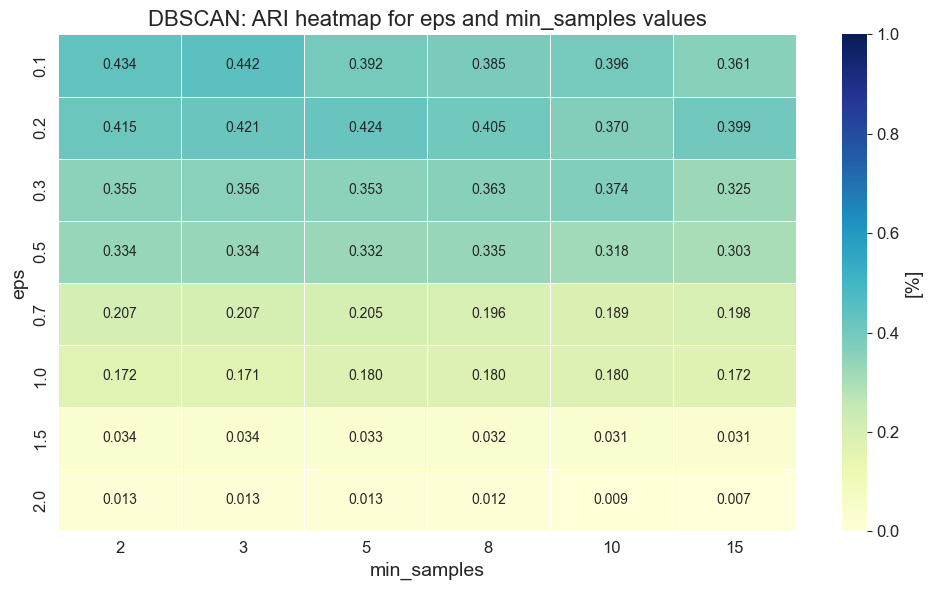

In [ ]:
dbscan_metrics = metrics_df.loc[metrics_df["algorithm"].str.startswith("dbscan")].copy()
parsed_params = dbscan_metrics["algorithm"].str.extract(r"dbscan_eps_([0-9.]+)_min_samples_(\d+)")
dbscan_metrics["eps"] = parsed_params[0].astype(float)
dbscan_metrics["min_samples"] = parsed_params[1].astype(int)
dbscan_metrics = dbscan_metrics.dropna(subset=["ARI", "eps", "min_samples"])

dbscan_summary = (
    dbscan_metrics.groupby(["eps", "min_samples"], as_index=False)["ARI"]
    .mean()
    .sort_values(["min_samples", "eps"])
)

best_configurations = dbscan_summary.sort_values("ARI", ascending=False).head(10)

dbscan_heatmap = dbscan_summary.pivot(index="eps", columns="min_samples", values="ARI")

fig, ax = plt.subplots(figsize=(10, 6))
hm = sns.heatmap(
    dbscan_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "ARI"},
    ax=ax,
)
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("[%]", fontsize=14)
ax.set_title("DBSCAN: ARI heatmap for eps and min_samples values", fontsize=16)
ax.set_xlabel("min_samples", fontsize=14)
ax.set_ylabel("eps", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=12)
fig.tight_layout()

plot_path = "../outputs/plots/dbscan_ari_eps_min_samples.png"
fig.savefig(plot_path, dpi=500, bbox_inches="tight")
plt.show()

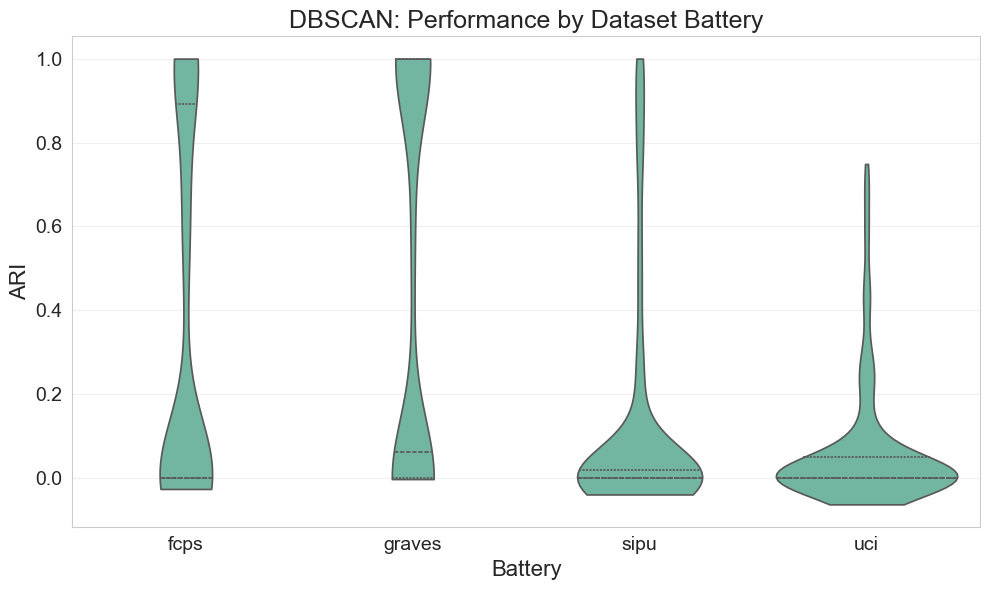

DBSCAN performance by battery:
         count    min    max  median   mean    std
battery                                           
fcps       432 -0.025  1.000   0.000  0.349  0.433
graves     480 -0.002  1.000   0.062  0.460  0.478
sipu       768 -0.039  1.000   0.000  0.123  0.271
uci        384 -0.062  0.749   0.000  0.069  0.153

Best DBSCAN configurations by battery:
battery  eps  min_samples      ARI
   fcps  0.7            2 1.000000
 graves  0.1            8 1.000000
   sipu  0.2           15 1.000000
    uci  0.1            5 0.748956


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=dbscan_metrics,
    x="battery",
    y="ARI",
    ax=ax,
    inner="quartile",
    cut=0,
)
ax.set_xlabel("Battery", fontsize=16)
ax.set_ylabel("ARI", fontsize=16)
ax.set_title("DBSCAN: Performance by Dataset Battery", fontsize=18)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="both", which="major", labelsize=14)

fig.tight_layout()
fig.savefig("../outputs/plots/dbscan_ari_by_battery.png", dpi=500, bbox_inches="tight")
plt.show()

print("DBSCAN performance by battery:")
battery_summary = (
    dbscan_metrics.groupby("battery")["ARI"]
    .agg(["count", "min", "max", "median", "mean", "std"])
    .round(3)
)
print(battery_summary)

best_configurations_by_battery = (
    dbscan_metrics.loc[
        dbscan_metrics.groupby("battery")["ARI"].idxmax(), ["battery", "eps", "min_samples", "ARI"]
    ]
    .sort_values("battery")
    .reset_index(drop=True)
)

print("\nBest DBSCAN configurations by battery:")
print(best_configurations_by_battery.to_string(index=False))

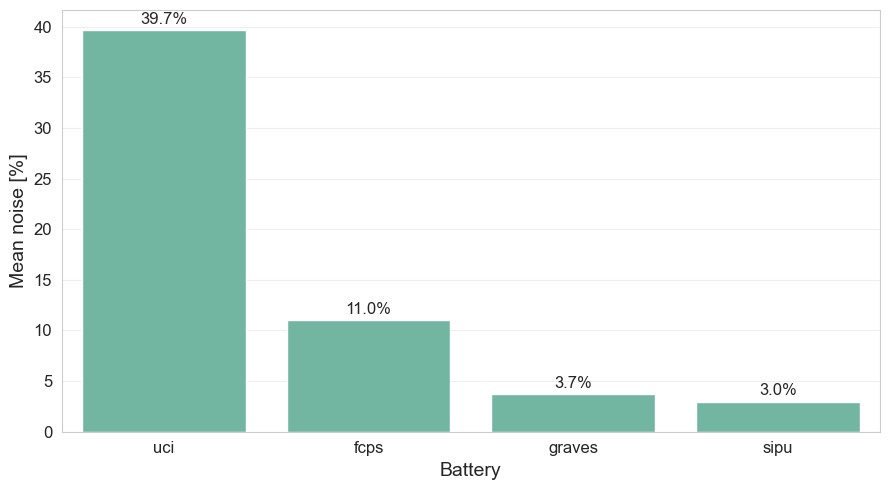

,battery,noise_pct
3,uci,39.673579
0,fcps,11.049011
1,graves,3.738421
2,sipu,2.984341


In [ ]:
dbscan_noise = labels_df.loc[labels_df["algorithm"].str.startswith("dbscan")].copy()
dbscan_noise["battery"] = dbscan_noise["dataset"].str.split("/").str[0]
dbscan_noise["noise_pct"] = dbscan_noise["labels"].map(
    lambda arr: float((np.asarray(arr) == -1).mean() * 100)
)

noise_by_battery = (
    dbscan_noise.groupby("battery", as_index=False)["noise_pct"]
    .mean()
    .sort_values("noise_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=noise_by_battery,
    x="battery",
    y="noise_pct",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Battery", fontsize=14)
ax.set_ylabel("Mean noise [%]", fontsize=14)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(labelsize=12)

for i, value in enumerate(noise_by_battery["noise_pct"]):
    ax.text(i, value + 0.3, f"{value:.1f}%", ha="center", va="bottom", fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/plots/dbscan_mean_noise_pct_by_battery.png", dpi=500, bbox_inches="tight")
plt.show()

noise_by_battery

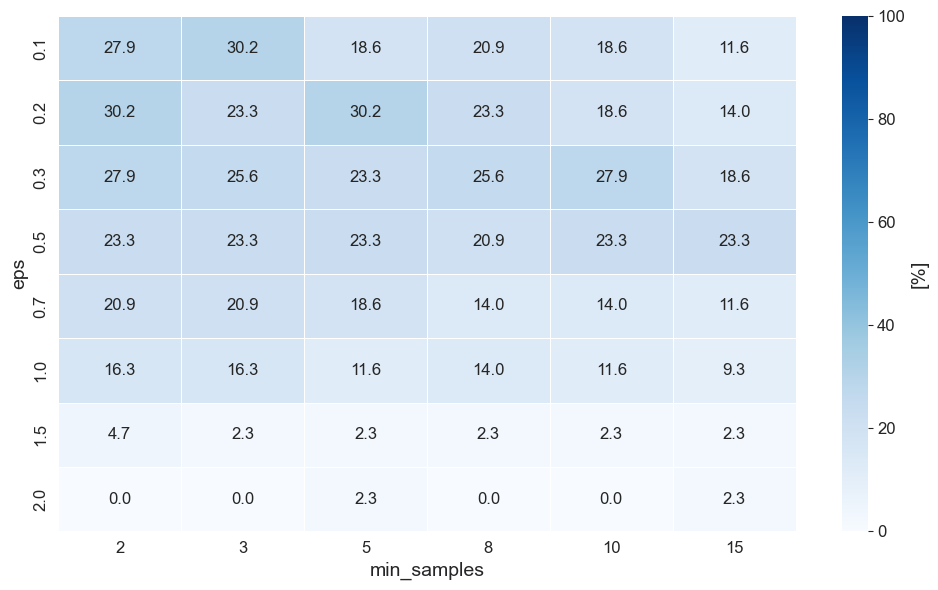

,eps,min_samples,n_correct,n_total,accuracy_pct
1,0.1,3,13,43,30.232558
6,0.2,2,13,43,30.232558
8,0.2,5,13,43,30.232558
16,0.3,10,12,43,27.906977
0,0.1,2,12,43,27.906977
12,0.3,2,12,43,27.906977
13,0.3,3,11,43,25.581395
15,0.3,8,11,43,25.581395
22,0.5,10,10,43,23.255814
23,0.5,15,10,43,23.255814


In [ ]:
dbscan_labels = labels_df.loc[labels_df["algorithm"].str.startswith("dbscan")].copy()

parsed_cfg = dbscan_labels["algorithm"].str.extract(r"dbscan_eps_([0-9.]+)_min_samples_(\d+)")
dbscan_labels["eps"] = parsed_cfg[0].astype(float)
dbscan_labels["min_samples"] = parsed_cfg[1].astype(int)

dbscan_labels["true_k"] = dbscan_labels["true_labels"].map(
    lambda arr: np.unique(np.asarray(arr)).size
)
dbscan_labels["pred_k"] = dbscan_labels["labels"].map(
    lambda arr: np.unique(np.asarray(arr)[np.asarray(arr) != -1]).size
)
dbscan_labels["correct_k"] = (dbscan_labels["pred_k"] == dbscan_labels["true_k"]).astype(int)

dbscan_correct_counts = dbscan_labels.groupby(["eps", "min_samples"], as_index=False)[
    "correct_k"
].agg(n_correct="sum", n_total="count")
dbscan_correct_counts["accuracy_pct"] = (
    100.0 * dbscan_correct_counts["n_correct"] / dbscan_correct_counts["n_total"]
)
dbscan_correct_counts = dbscan_correct_counts.sort_values(["min_samples", "eps"])

dbscan_correct_heatmap = dbscan_correct_counts.pivot(
    index="eps", columns="min_samples", values="accuracy_pct"
)

fig, ax = plt.subplots(figsize=(10, 6))
hm = sns.heatmap(
    dbscan_correct_heatmap,
    annot=True,
    annot_kws={"fontsize": 12},
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "[%]"},
    ax=ax,
)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("[%]", fontsize=14)
# ax.set_title("DBSCAN: procent trafien poprawnej liczby klastrow (eps, min_samples)")
ax.set_xlabel("min_samples", fontsize=14)
ax.set_ylabel("eps", fontsize=14)
ax.tick_params(labelsize=12)
fig.tight_layout()
fig.savefig(
    "../outputs/plots/dbscan_correct_cluster_pct_by_config.png", dpi=500, bbox_inches="tight"
)
plt.show()

dbscan_correct_counts.sort_values("accuracy_pct", ascending=False).head(10)

## Agglomerative parameter analysis

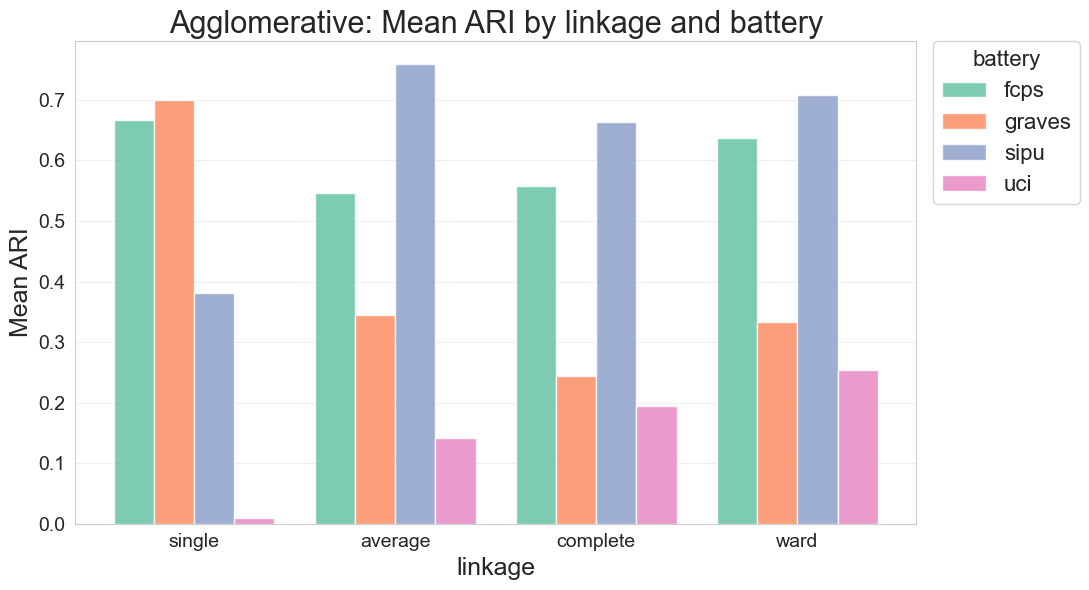

In [13]:
agglomerative_metrics = metrics_df.loc[
    metrics_df["algorithm"].str.startswith("agglomerative")
].copy()
linkage_order = ["single", "average", "complete", "ward"]
agglomerative_metrics["linkage"] = pd.Categorical(
    agglomerative_metrics["algorithm"].str.replace("agglomerative_", "", regex=False),
    categories=linkage_order,
    ordered=True,
)
agglomerative_metrics = agglomerative_metrics.dropna(subset=["ARI", "linkage", "battery"])

agglomerative_summary = (
    agglomerative_metrics.groupby(["linkage", "battery"], as_index=False)["ARI"]
    .agg(["mean", "std"])
    .reset_index()
)
agglomerative_summary["linkage"] = pd.Categorical(
    agglomerative_summary["linkage"], categories=linkage_order, ordered=True
)
agglomerative_summary = agglomerative_summary.sort_values(["linkage", "battery"])

best_agglomerative = (
    agglomerative_summary.sort_values("mean", ascending=False)
    .head(10)
    .rename(columns={"mean": "mean_ARI", "std": "std_ARI"})
)

battery_order = sorted(agglomerative_metrics["battery"].dropna().unique())
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(linkage_order))
width = 0.8 / max(len(battery_order), 1)
for i, battery in enumerate(battery_order):
    subset = agglomerative_summary[agglomerative_summary["battery"] == battery].set_index("linkage")
    means = subset.reindex(linkage_order)["mean"].to_numpy()
    stds = subset.reindex(linkage_order)["std"].fillna(0.0).to_numpy()
    positions = x - 0.4 + width / 2 + i * width
    ax.bar(
        positions,
        means,
        width=width,
        label=battery,
        capsize=4,
        alpha=0.85,
    )

ax.set_xticks(x)
ax.set_xticklabels(linkage_order, fontsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_xlabel("linkage", fontsize=18)
ax.set_ylabel("Mean ARI", fontsize=18)
ax.set_title("Agglomerative: Mean ARI by linkage and battery", fontsize=22)
ax.grid(axis="y", alpha=0.3)
ax.grid(axis="x", alpha=0.0)
ax.legend(
    title="battery",
    title_fontsize=16,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    fontsize=16,
)

fig.tight_layout()
fig.savefig("../outputs/plots/agglomerative_ari_linkage.png", dpi=500, bbox_inches="tight")
plt.show()

## Genie parameter analysis

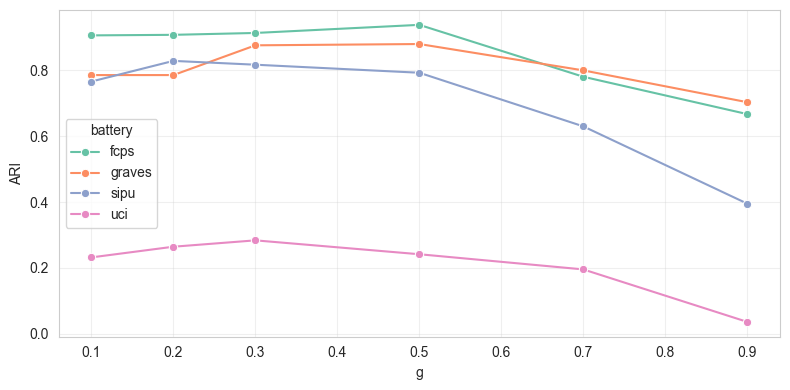

In [14]:
genie_metrics = metrics_df.loc[metrics_df["algorithm"].str.startswith("genie")].copy()
parsed_genie = genie_metrics["algorithm"].str.extract(r"genie_g_([0-9.]+)")
genie_metrics["g"] = parsed_genie[0].astype(float)
genie_metrics = genie_metrics.dropna(subset=["ARI", "g"])

genie_summary = (
    genie_metrics.groupby(["battery", "g"], as_index=False)["ARI"]
    .mean()
    .sort_values(["battery", "g"])
)

best_genie = genie_summary.sort_values("ARI", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(
    data=genie_summary,
    x="g",
    y="ARI",
    hue="battery",
    marker="o",
    ax=ax,
)
# ax.set_title("Genie: ARI vs g values")
ax.set_xlabel("g")
ax.set_ylabel("ARI")
ax.grid(alpha=0.3)
ax.legend(title="battery", loc="best")

fig.tight_layout()
fig.savefig("../outputs/plots/genie_ari_g.png", dpi=500, bbox_inches="tight")
plt.show()

## Metric analysis

In [ ]:
external_metric_cols = ["ARI", "NMI", "NCA"]

external_long = metrics_df.melt(
    id_vars=["dataset", "battery", "algorithm"],
    value_vars=external_metric_cols,
    var_name="metric",
    value_name="score",
)

external_long["algorithm_merged"] = external_long["algorithm"].map(
    lambda a: (
        "dbscan"
        if a.startswith("dbscan")
        else (
            "genie"
            if a.startswith("genie")
            else ("agglomerative" if a.startswith("agglomerative") else a)
        )
    )
)

algo_plot_order = [
    "dbscan",
    "genie",
    "agglomerative",
    *sorted(
        [
            a
            for a in external_long["algorithm_merged"].dropna().unique()
            if a not in {"dbscan", "genie", "agglomerative"}
        ]
    ),
]
battery_plot_order = sorted(external_long["battery"].dropna().unique())

external_long = external_long.dropna(subset=["score"])
external_long.head()

,dataset,battery,algorithm,metric,score,algorithm_merged
0,fcps/atom,fcps,kmeans,ARI,0.192907,kmeans
1,fcps/atom,fcps,gaussian_mixture,ARI,0.080663,gaussian_mixture
2,fcps/atom,fcps,genie_g_0.1,ARI,1.000000,genie
3,fcps/atom,fcps,genie_g_0.2,ARI,1.000000,genie
4,fcps/atom,fcps,genie_g_0.3,ARI,1.000000,genie


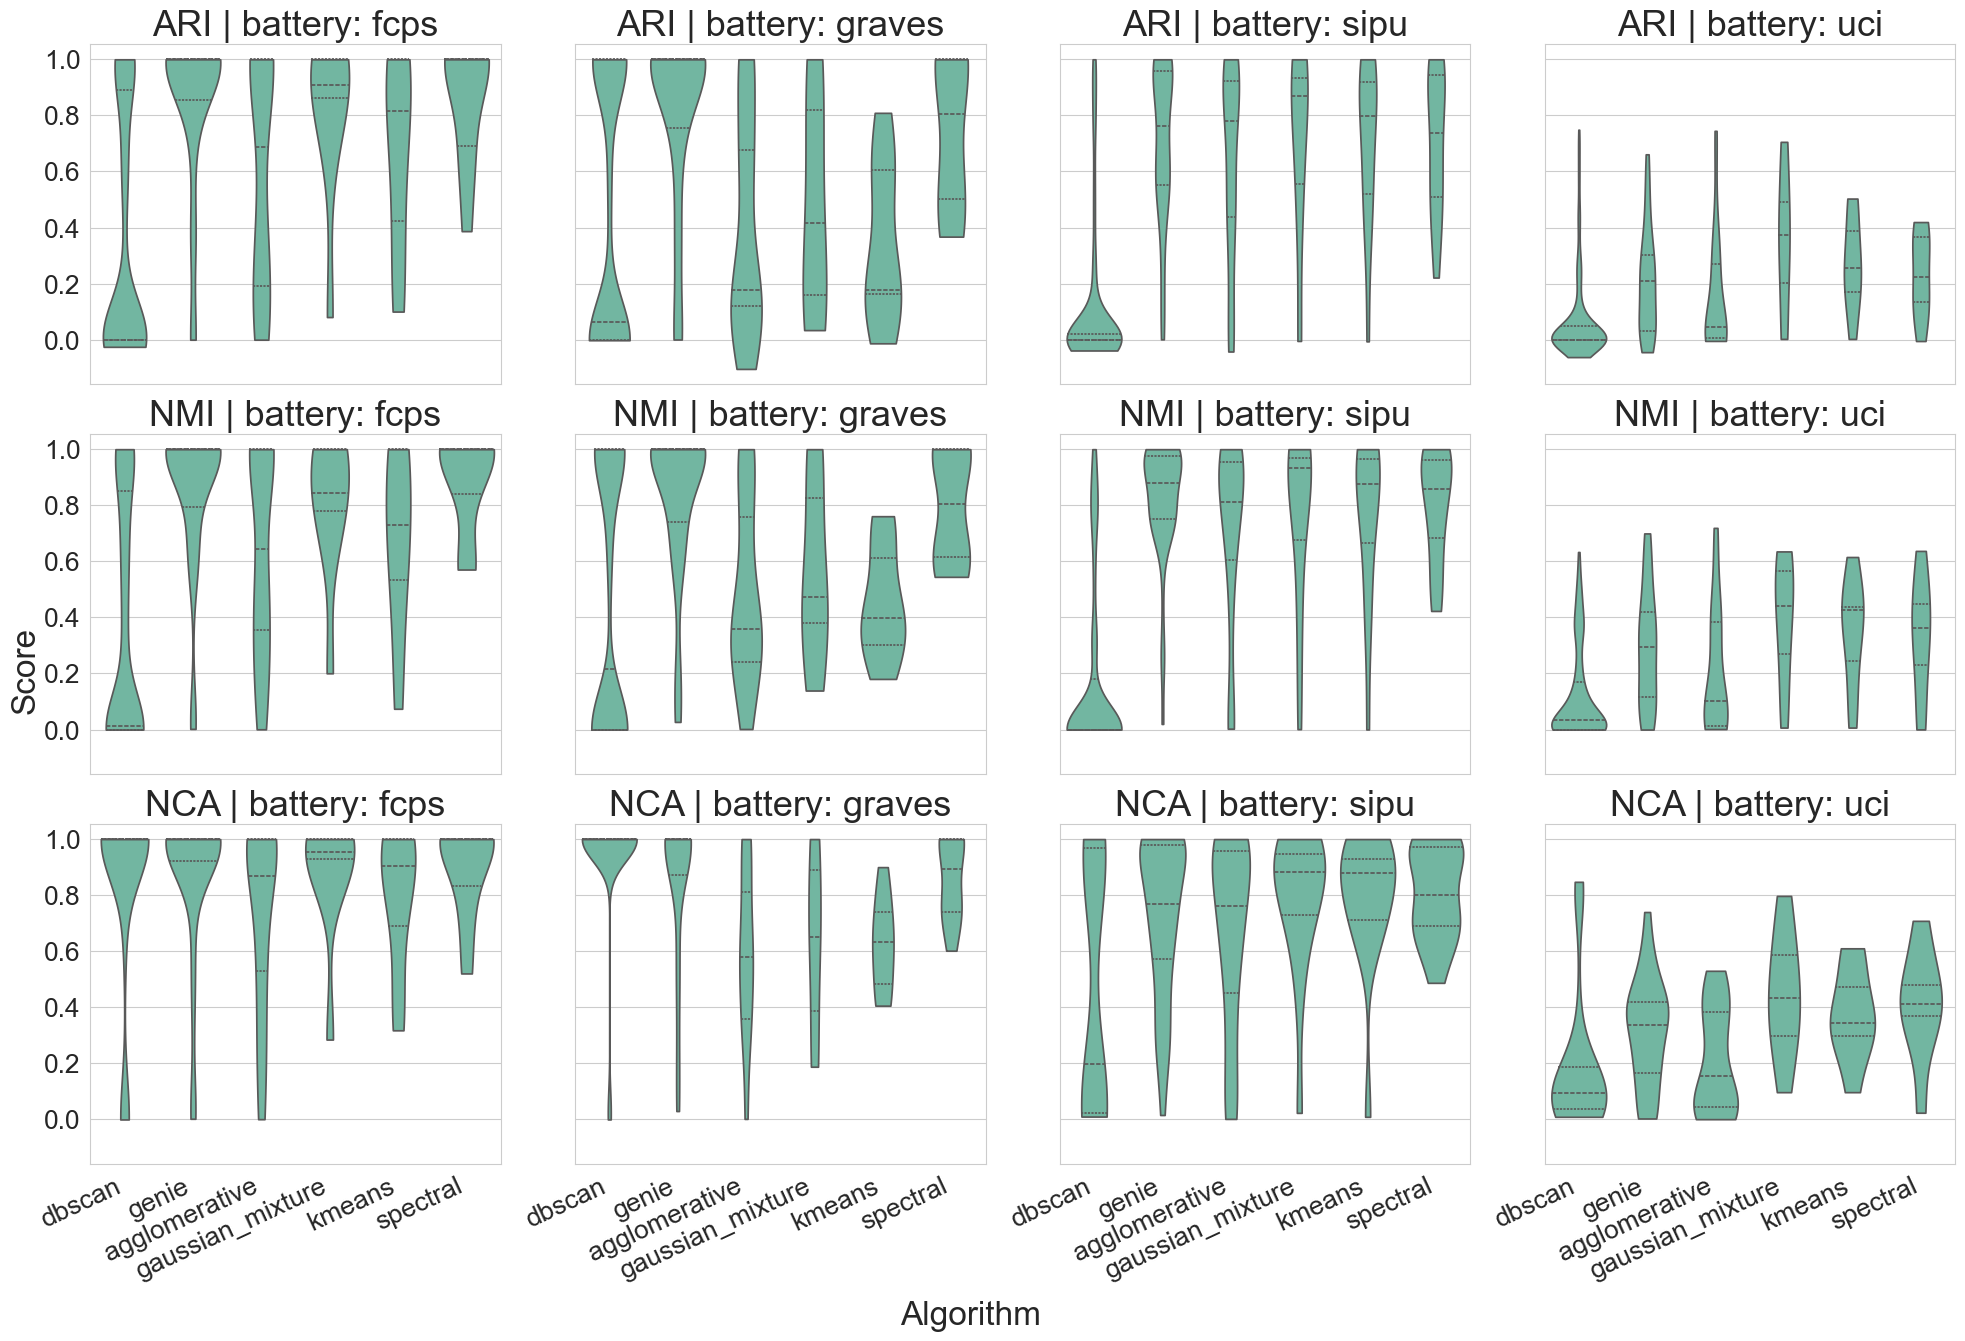

In [ ]:
ncols = len(battery_plot_order)
nrows = len(external_metric_cols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), sharey=True, sharex=True)
axes = np.atleast_2d(axes)

for i, metric in enumerate(external_metric_cols):
    for j, battery in enumerate(battery_plot_order):
        ax = axes[i, j]
        subset = external_long[
            (external_long["metric"] == metric) & (external_long["battery"] == battery)
        ]
        sns.violinplot(
            data=subset,
            x="algorithm_merged",
            y="score",
            order=algo_plot_order,
            ax=ax,
            inner="quartile",
            cut=0,
        )
        ax.set_title(f"{metric} | battery: {battery}", fontsize=26)
        ax.set_xlabel("", fontsize=22)
        ax.set_ylabel("", fontsize=19)
        ax.tick_params(axis="x", rotation=25, labelsize=19)

        plt.setp(ax.get_xticklabels(), ha="right")

        if j == 0:
            ax.set_yticklabels(ax.get_yticklabels(), fontsize=19)

# fig.suptitle("External metrics density and spread", fontsize=30, y=1.001)
fig.supxlabel("Algorithm", fontsize=24)
fig.supylabel("Score", fontsize=24)
plt.tight_layout()
plt.savefig("../outputs/plots/external_metrics_violin.png", dpi=500, bbox_inches="tight")
plt.show()

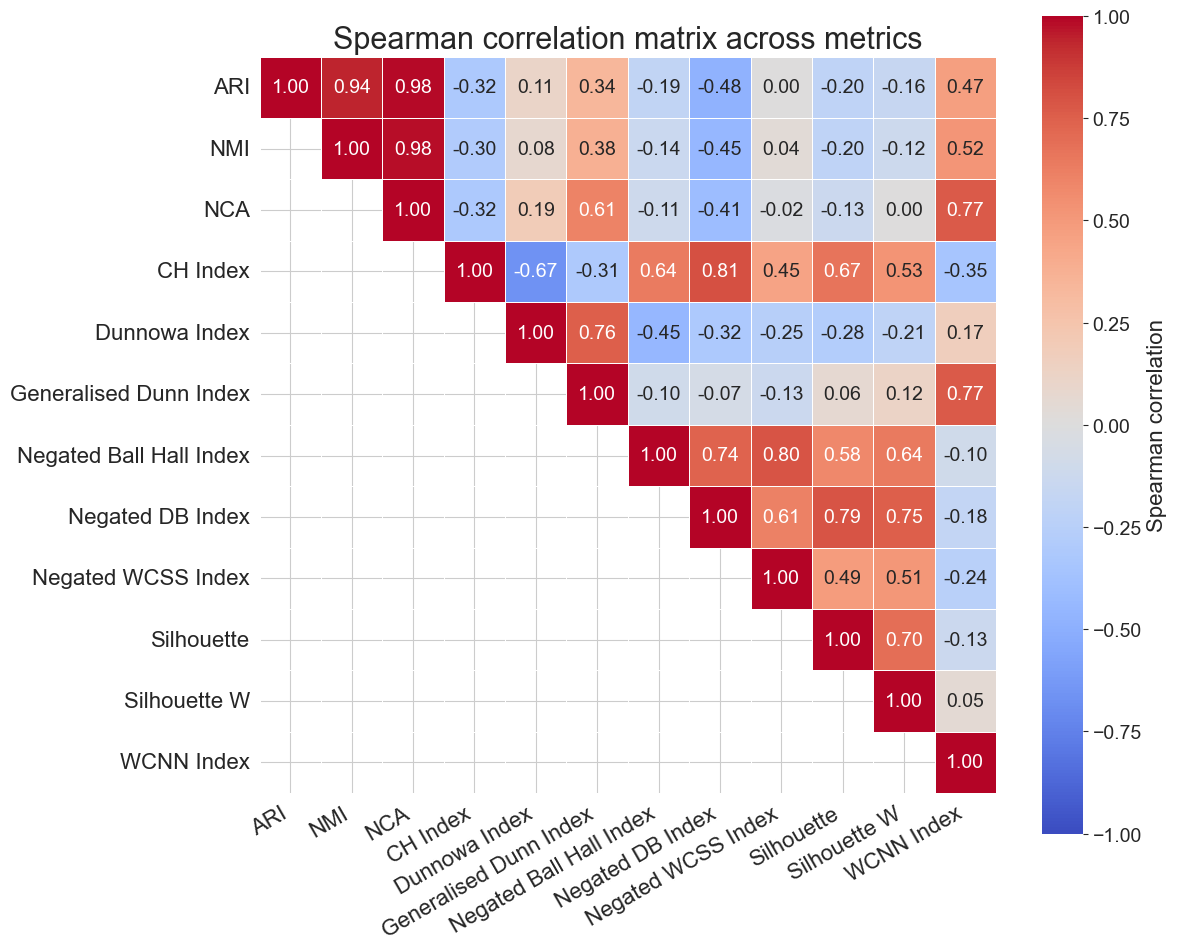

In [ ]:
all_metric_cols = [c for c in (external_metrics + internal_metrics) if c in metrics_df.columns]

corr_spearman = metrics_df[all_metric_cols].corr(method="spearman")

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={"label": "Spearman correlation"},
    annot_kws={"size": 14},
    mask=np.tril(np.ones_like(corr_spearman, dtype=bool), k=-1),
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Spearman correlation", fontsize=16)
plt.title("Spearman correlation matrix across metrics", fontsize=22)
plt.xticks(rotation=30, ha="right", fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/plots/metric_spearman_correlation.png", dpi=500)
plt.show()

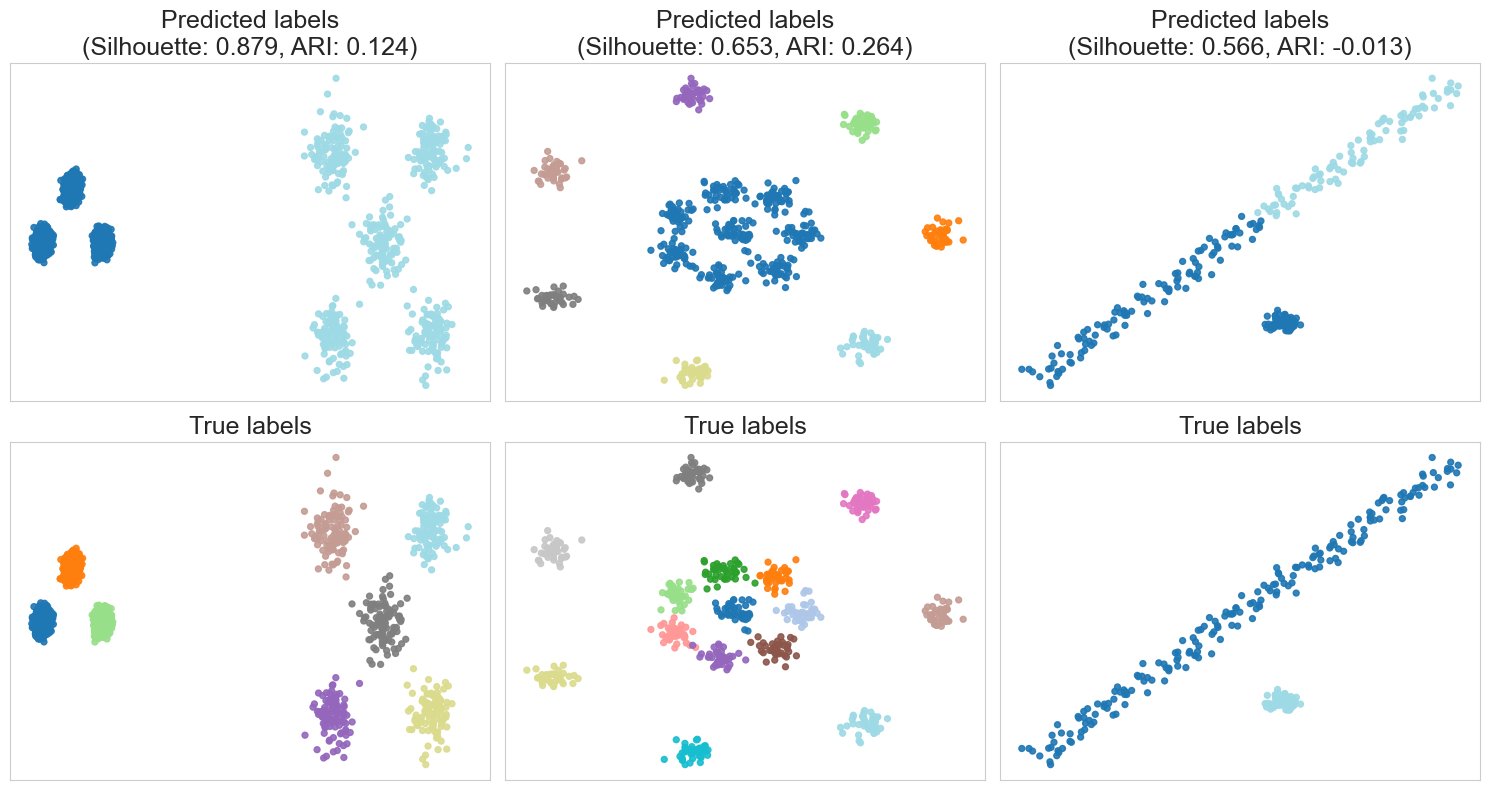

In [ ]:
scatter_df = metrics_df.copy()
scatter_df = scatter_df.dropna(subset=["Silhouette", "ARI", "algorithm", "dataset"])
scatter_df["algorithm_group"] = scatter_df["algorithm"].map(
    lambda a: (
        "dbscan"
        if a.startswith("dbscan")
        else (
            "genie"
            if a.startswith("genie")
            else ("agglomerative" if a.startswith("agglomerative") else a)
        )
    )
)

labels_subset = labels_df[
    ["dataset", "algorithm", "data", "labels", "true_labels"]
].drop_duplicates(subset=["dataset", "algorithm"])
analysis_df = scatter_df.merge(labels_subset, on=["dataset", "algorithm"], how="inner")

analysis_df["is_2d"] = analysis_df["data"].map(
    lambda arr: isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[1] == 2
)
analysis_df = analysis_df[analysis_df["is_2d"]].copy()

sil_threshold = analysis_df["Silhouette"].quantile(0.75)
ari_threshold = analysis_df["ARI"].quantile(0.25)

candidates = analysis_df[
    (analysis_df["Silhouette"] >= sil_threshold) & (analysis_df["ARI"] <= ari_threshold)
].copy()
candidates = candidates.sort_values(["Silhouette", "ARI"], ascending=[False, True])

if candidates.empty:
    print("Brak przypadków spełniających progi kwartylowe; używam najmocniejszego kontrastu.")
    candidates = analysis_df.sort_values(["Silhouette", "ARI"], ascending=[False, True]).head(12)

candidates = candidates.drop_duplicates(subset=["dataset"], keep="first").head(4)

n_examples = len(candidates)
fig, axes = plt.subplots(2, n_examples, figsize=(5 * n_examples, 8), squeeze=False)

for i, row in enumerate(candidates.itertuples(index=False)):
    X = row.data
    y_pred = np.asarray(row.labels)
    y_true = np.asarray(row.true_labels)

    y_pred_codes = pd.factorize(y_pred)[0]
    y_true_codes = pd.factorize(y_true)[0]

    axes[0, i].scatter(X[:, 0], X[:, 1], c=y_pred_codes, s=18, cmap="tab20", alpha=0.9)
    axes[0, i].set_title(
        f"Predicted labels\n(Silhouette: {row.Silhouette:.3f}, ARI: {row.ARI:.3f})",
        fontsize=18,
    )
    axes[0, i].set_xticklabels([])
    axes[0, i].set_yticklabels([])
    axes[0, i].grid(alpha=0.0)

    axes[1, i].scatter(X[:, 0], X[:, 1], c=y_true_codes, s=18, cmap="tab20", alpha=0.9)
    axes[1, i].set_title("True labels", fontsize=18)
    axes[1, i].set_xticklabels([])
    axes[1, i].set_yticklabels([])
    axes[1, i].grid(alpha=0.0)

# fig.suptitle("High Silhouette, Low ARI Examples", fontsize=14)
fig.tight_layout()
fig.savefig(
    "../outputs/plots/high_silhouette_low_ari_examples.png",
    dpi=500,
    bbox_inches="tight",
)
plt.show()

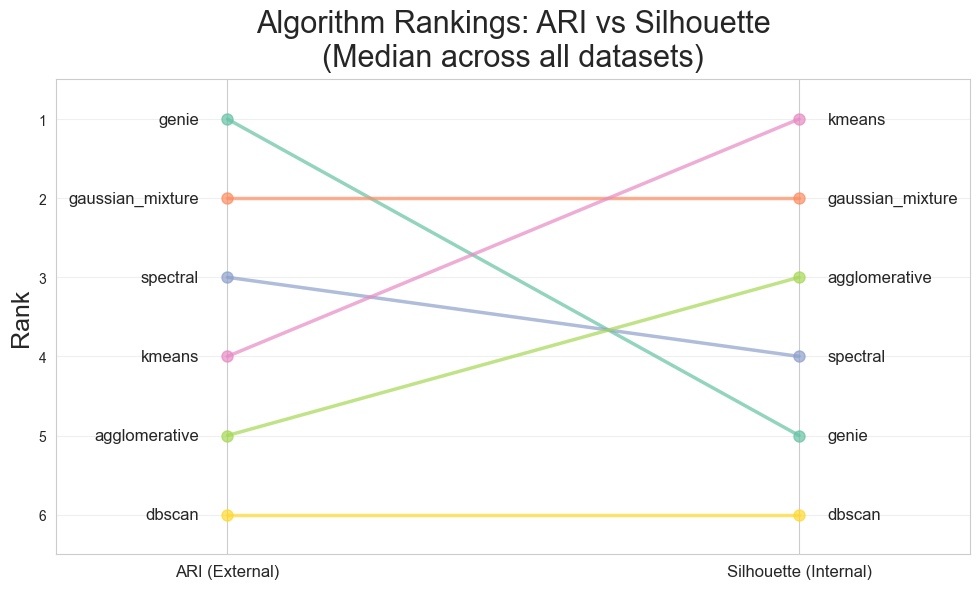

In [ ]:
algo_metrics = metrics_df.copy()
algo_metrics["algorithm_group"] = algo_metrics["algorithm"].map(
    lambda a: (
        "dbscan"
        if a.startswith("dbscan")
        else (
            "genie"
            if a.startswith("genie")
            else ("agglomerative" if a.startswith("agglomerative") else a)
        )
    )
)

ari_ranking = (
    algo_metrics.groupby("algorithm_group")["ARI"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"ARI": "median_ARI"})
)
ari_ranking["rank_ari"] = range(1, len(ari_ranking) + 1)

silhouette_ranking = (
    algo_metrics.groupby("algorithm_group")["Silhouette"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Silhouette": "median_Silhouette"})
)
silhouette_ranking["rank_silhouette"] = range(1, len(silhouette_ranking) + 1)

ranking_comparison = ari_ranking.merge(silhouette_ranking, on="algorithm_group")
top3_ari = set(ari_ranking.head(3)["algorithm_group"])
top3_sil = set(silhouette_ranking.head(3)["algorithm_group"])

fig, ax = plt.subplots(figsize=(10, 6))

for _idx, row in ranking_comparison.iterrows():
    algo = row["algorithm_group"]
    r_ari = row["rank_ari"]
    r_sil = row["rank_silhouette"]

    ax.plot([0, 1], [r_ari, r_sil], linewidth=2.5, marker="o", markersize=8, alpha=0.7)

    ax.text(-0.05, r_ari, f"{algo}", fontsize=12, ha="right", va="center")

    ax.text(1.05, r_sil, f"{algo}", fontsize=12, ha="left", va="center")

ax.set_xlim(-0.3, 1.3)
ax.set_ylim(len(ranking_comparison) + 0.5, 0.5)
ax.set_xticks([0, 1])
ax.xaxis_inverted()
ax.set_xticklabels(["ARI (External)", "Silhouette (Internal)"], fontsize=12)
ax.set_ylabel("Rank", fontsize=18)
ax.set_yticks(range(len(ranking_comparison), 0, -1))

ax.grid(axis="y", alpha=0.3)
ax.set_title(
    "Algorithm Rankings: ARI vs Silhouette\n(Median across all datasets)",
    fontsize=22,
    pad=10,
)
fig.tight_layout()
fig.savefig("../outputs/plots/algorithm_rankings_slopegraph.png", dpi=500, bbox_inches="tight")
plt.show()

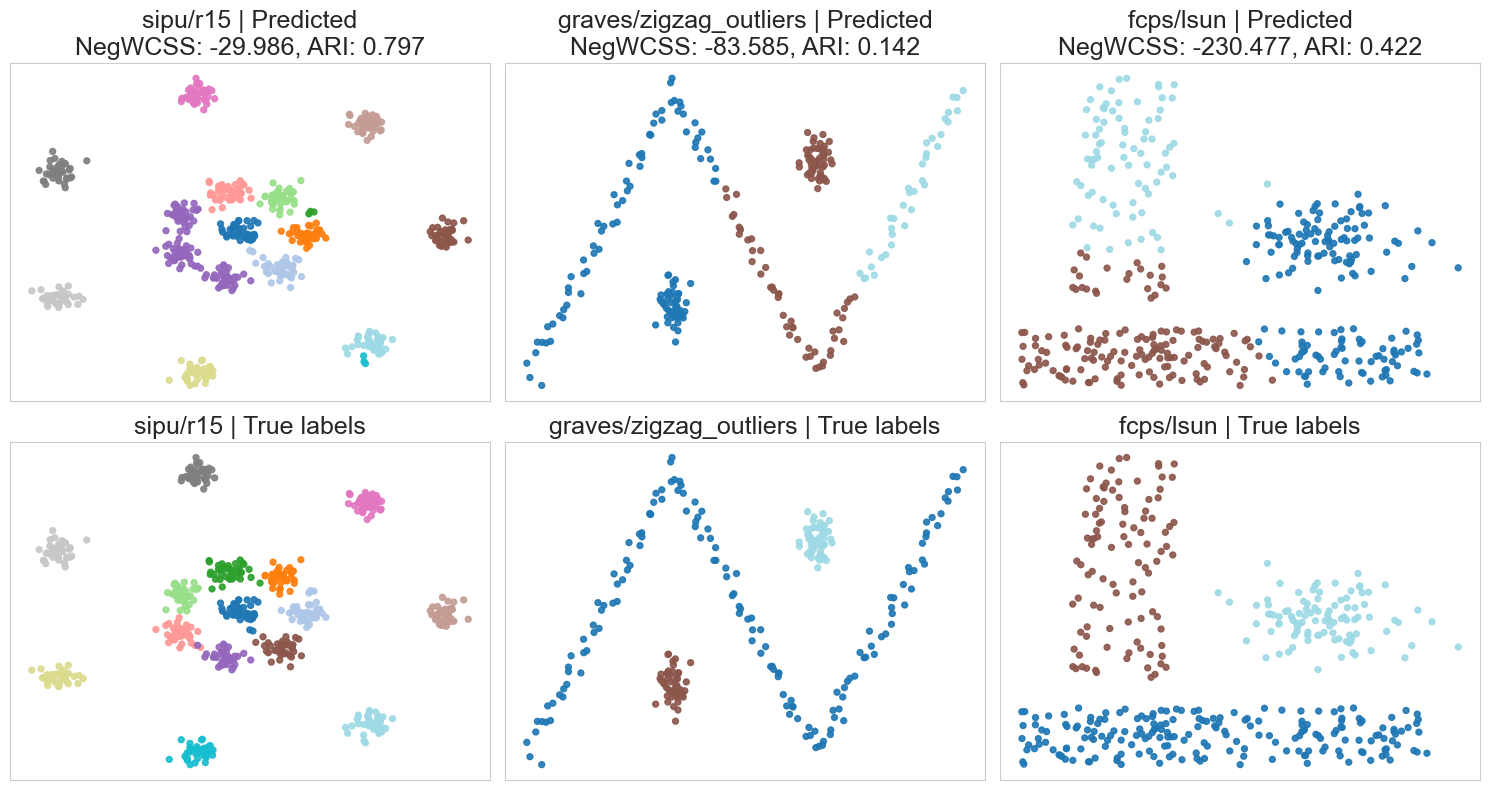

In [ ]:
neg_wcss_df = metrics_df.copy()
neg_wcss_df = neg_wcss_df.dropna(subset=["Negated WCSS Index", "ARI", "algorithm", "dataset"])
neg_wcss_df["algorithm_group"] = neg_wcss_df["algorithm"].map(
    lambda a: (
        "dbscan"
        if a.startswith("dbscan")
        else (
            "genie"
            if a.startswith("genie")
            else ("agglomerative" if a.startswith("agglomerative") else a)
        )
    )
)


labels_subset = labels_df[
    ["dataset", "algorithm", "data", "labels", "true_labels"]
].drop_duplicates(subset=["dataset", "algorithm"])
neg_wcss_examples = neg_wcss_df.merge(labels_subset, on=["dataset", "algorithm"], how="inner")
neg_wcss_examples = neg_wcss_examples.rename(columns={"Negated WCSS Index": "Negated_WCSS_Index"})

neg_wcss_examples["is_2d"] = neg_wcss_examples["data"].map(
    lambda arr: isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[1] == 2
)
neg_wcss_examples = neg_wcss_examples[neg_wcss_examples["is_2d"]].copy()

neg_wcss_threshold = neg_wcss_examples["Negated_WCSS_Index"].quantile(0.70)
ari_threshold = neg_wcss_examples["ARI"].quantile(0.50)

candidates_wcss = neg_wcss_examples[
    (neg_wcss_examples["Negated_WCSS_Index"] >= neg_wcss_threshold)
    & (neg_wcss_examples["ARI"] <= ari_threshold)
].copy()

if candidates_wcss.empty:
    candidates_wcss = neg_wcss_examples.copy()

candidates_wcss = candidates_wcss.sort_values(
    ["Negated_WCSS_Index", "ARI"], ascending=[False, True]
)

candidates_wcss = (
    candidates_wcss.groupby("battery", as_index=False, sort=False).head(1).head(4).copy()
)

n_examples = len(candidates_wcss)
fig, axes = plt.subplots(2, n_examples, figsize=(5 * n_examples, 8), squeeze=False)

for i, (_, row) in enumerate(candidates_wcss.iterrows()):
    X = row["data"]
    y_pred = np.asarray(row["labels"])
    y_true = np.asarray(row["true_labels"])

    y_pred_codes = pd.factorize(y_pred)[0]
    y_true_codes = pd.factorize(y_true)[0]

    axes[0, i].scatter(X[:, 0], X[:, 1], c=y_pred_codes, s=18, cmap="tab20", alpha=0.9)
    axes[0, i].set_title(
        f"{row['dataset']} "
        + f"| Predicted\nNegWCSS: {row['Negated_WCSS_Index']:.3f}, ARI: {row['ARI']:.3f}",
        fontsize=18,
    )
    axes[0, i].set_xticklabels([])
    axes[0, i].set_yticklabels([])
    axes[0, i].grid(alpha=0.0)

    axes[1, i].scatter(X[:, 0], X[:, 1], c=y_true_codes, s=18, cmap="tab20", alpha=0.9)
    axes[1, i].set_title(f"{row['dataset']} | True labels", fontsize=18)
    axes[1, i].set_xticklabels([])
    axes[1, i].set_yticklabels([])
    axes[1, i].grid(alpha=0.0)

for i in range(n_examples):
    axes[0, i].set_xlabel("")
    axes[0, i].set_ylabel("")
    axes[1, i].set_xlabel("")
    axes[1, i].set_ylabel("")

# fig.suptitle("High Negated WCSS, Low ARI Examples", fontsize=14)
fig.tight_layout()
fig.savefig(
    "../outputs/plots/high_negated_wcss_low_ari_examples.png",
    dpi=500,
    bbox_inches="tight",
)
plt.show()